In [5]:
import os
import uuid
import imageio
import numpy as np
from IPython.display import Image as ImageDisplay

from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer
import torch



In [23]:
# Verify it's all there
outputs = torch.load("sam3d_object_cache.pt")
print(outputs[0].keys())
print(outputs[1].keys())
print(outputs[2].keys())
print(outputs[3].keys())
# Access your intrinsics directly
print(outputs[0]['coords'].shape)
print(outputs[0]['pointmap'].shape)

/tmp/ipykernel_1435/3950717317.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load("sam3d_object_cache.pt")


dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
torch.Size([10086, 4])
torch.Size([480, 640, 3])


(960, 1280)


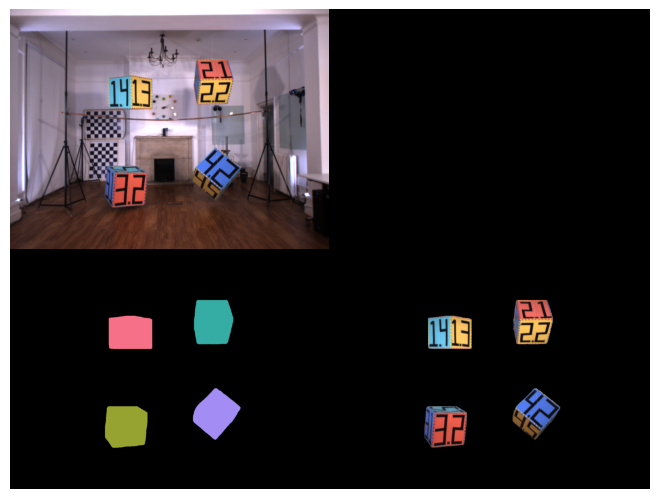

In [28]:
PATH = os.getcwd()
IMAGE_PATH = f"{PATH}/../../tracking_dataset/omd_mask/000001/image.png"
IMAGE_NAME = os.path.basename(os.path.dirname(IMAGE_PATH))

image = load_image(IMAGE_PATH)
masks = load_masks(os.path.dirname(IMAGE_PATH), indices_list=[0, 1, 2, 4], extension=".png")
display_image(image, masks)
print(masks[0].shape)

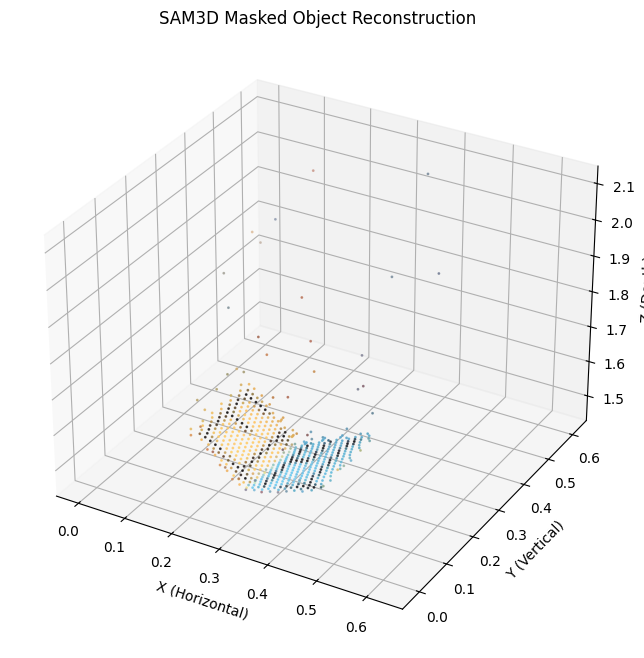

In [41]:
import open3d as o3d
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_sam3d_output(output_dict, binary_mask, colors=None, decimate_ratio=0.1):
    """
    Visualizes the pointmap and pointmap_colors from SAM3D meta output.
    """
    # 1. Extract data
    # Shape of pointmap is usually (H, W, 3)
    points = output_dict.get('pointmap')
    colors = output_dict.get('pointmap_colors')
    coords = output_dict['coords']

    if points is None:
        print("Error: 'pointmap' not found in dictionary.")
        return

    if isinstance(binary_mask, np.ndarray):
        binary_mask = torch.from_numpy(binary_mask)

    mask_rescaled = F.interpolate(
        binary_mask.unsqueeze(0).unsqueeze(0).float(), 
        size=(points.shape[0], points.shape[1]), 
        mode='nearest'
    ).squeeze()
    
    y_indices, x_indices = torch.where(mask_rescaled > 0)
    y_indices = y_indices.to(points.device)
    x_indices = x_indices.to(points.device)
    filtered_points = points[y_indices, x_indices]
    filtered_colors = colors[y_indices, x_indices]

    # 2. Reshape/Flatten the grids
    # We turn the (H, W, 3) image-like grid into a long list of (N, 3) points
    flat_points = filtered_points.reshape(-1, 3)
    
    # 3. Handle Colors
    if colors is not None:
        flat_colors = filtered_colors.reshape(-1, 3)
        # Ensure colors are in float range [0, 1] for Open3D
        if flat_colors.max() > 1.0:
            flat_colors = flat_colors / 255.0
    else:
        # Default to gray if no colors provided
        flat_colors = np.ones_like(flat_points) * 0.5

    # 4. Filter out invalid points (zeros or NaNs)
    # Monocular depth often produces 0s for pixels it couldn't estimate
    valid_idx = ~(flat_points == 0).all(dim=1)
    final_points = flat_points[valid_idx]
    final_colors = flat_colors[valid_idx]

    # # 5. Create Open3D PointCloud
    # pcd = o3d.geometry.PointCloud()
    # pcd.points = o3d.utility.Vector3dVector(final_points)
    # pcd.colors = o3d.utility.Vector3dVector(final_colors)

    # # 6. Visualize
    # print("Opening 3D visualization... Use mouse to rotate, scroll to zoom.")
    # # Add a coordinate frame to see the origin (Camera center)
    # coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])
    # o3d.visualization.draw_geometries([pcd, coord_frame], 
    #                                   window_name="SAM3D Pointmap Visualization")

    # 4. Decimate (Skip points to improve Matplotlib performance)
    if decimate_ratio < 1.0:
        step = int(1 / decimate_ratio)
        pts = final_points[::step]
        if colors is not None:
            c_data = colors[mask_rescaled > 0][valid_idx][::step]
            if torch.is_tensor(c_data): c_data = c_data.detach().cpu().numpy()
            if c_data.max() > 1.0: c_data = c_data / 255.0
        else:
            c_data = 'blue'
    
    # 5. Create the Matplotlib Figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # X, Y, Z coordinates
    xs, ys, zs = pts[:, 0], pts[:, 1], pts[:, 2]

    # Scatter plot
    # Note: In Matplotlib, the Z-axis is usually "Up", 
    # but in Camera coordinates, Z is "Forward".
    img = ax.scatter(xs, ys, zs, c=c_data, s=1, alpha=0.8)

    # Set labels
    ax.set_xlabel('X (Horizontal)')
    ax.set_ylabel('Y (Vertical)')
    ax.set_zlabel('Z (Depth)')
    ax.set_title('SAM3D Masked Object Reconstruction')

    # Equalize axis (optional, but helps with perspective)
    max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
    mid_x = (xs.max()+xs.min()) * 0.5
    mid_y = (ys.max()+ys.min()) * 0.5
    mid_z = (zs.max()+zs.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# Example usage (assuming 'data' is your dictionary):
visualize_sam3d_output(outputs[0], masks[0])

In [7]:
# render output for depth
from sam3d_objects.model.backbone.tdfy_dit.utils import render_utils

intrinstics_to_use = [outputs[0]['intrinstics'], outputs[1]['intrinstics'], outputs[2]['intrinstics'], outputs[3]['intrinstics'],]
extrinsics_to_use = [torch.eye(4, device="cuda"), torch.eye(4, device="cuda"), torch.eye(4, device="cuda"), torch.eye(4, device="cuda")]
bg_color = [0.0, 0.0, 0.0]
scene_gs = make_scene(*outputs)
scene_gs = ready_gaussian_for_video_rendering(scene_gs)

render_result = render_utils.render_frames(
        sample=scene_gs,
        extrinsics=extrinsics_to_use,
        intrinsics=intrinstics_to_use,
        options={"bg_color": "random", 'backend': 'gsplat', "ssaa": 1})

Rendering: 0it [00:00, ?it/s]


AssertionError: torch.Size([1, 1])

In [ ]:
import numpy as np
import open3d as o3d

def align_sam3d_to_reference(sam_points, ref_points):
    """
    sam_points: (N, 3) matrix of points from the SAM3D output
    ref_points: (N, 3) matrix of ground truth/sparse points
    """
    # Create Open3D PointCloud objects
    p_sam = o3d.geometry.PointCloud()
    p_sam.points = o3d.utility.Vector3dVector(sam_points)
    
    p_ref = o3d.geometry.PointCloud()
    p_ref.points = o3d.utility.Vector3dVector(ref_points)

    # Use 'TransformationEstimationPointToPoint' with scaling set to True
    # This solves the Umeyama SVD problem
    estimate = o3d.pipelines.registration.TransformationEstimationPointToPoint(with_scaling=True)
    
    # We assume you have a 1-to-1 correspondence (indices match)
    # correspondences is an array of pairs [(0,0), (1,1), ..., (N,N)]
    corres = o3d.utility.Vector2iVector(np.arange(len(sam_points)).reshape(-1, 1).repeat(2, axis=1))
    
    T = estimate.compute_transformation(p_sam, p_ref, corres)
    return T

# Apply the resulting matrix T to your dense SAM3D mesh or Gaussian Splat
# mesh.transform(T)